In [ ]:
pip install xgboost


Saving Crop_recommendation.csv to Crop_recommendation.csv
✅ Dataset Loaded Successfully


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice



🚀 Training Hybrid Model...

🎯 Accuracy: 0.9954545454545455
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.

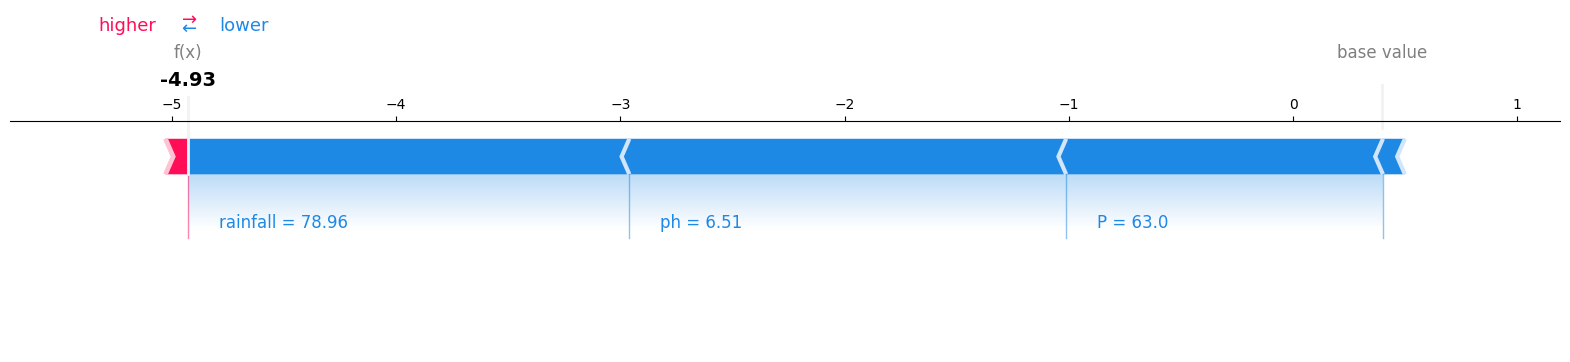


🌾 Crop Improvement Suggestions:

✅ N supports rice (value: 58.0)
⚠️ P is reducing rice suitability (value: 63.0)
✅ K supports rice (value: 81.0)
✅ temperature supports rice (value: 19.81)
⚠️ humidity is reducing rice suitability (value: 14.69)
⚠️ ph is reducing rice suitability (value: 6.51)
⚠️ rainfall is reducing rice suitability (value: 78.96)

✅ EXECUTION COMPLETED SUCCESSFULLY


In [2]:
# ============================================================
# HYBRID CROP RECOMMENDATION + SINGLE-CROP SHAP EXPLANATION
# ============================================================

!pip install -q shap xgboost

import numpy as np
import pandas as pd
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from google.colab import files

# ============================================================
# LOAD DATA
# ============================================================
uploaded = files.upload()
data = pd.read_csv(list(uploaded.keys())[0])

print("✅ Dataset Loaded Successfully")
display(data.head())

# ============================================================
# FEATURES & TARGET
# ============================================================
X = data.drop("label", axis=1)
y = data["label"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# ============================================================
# MODELS
# ============================================================
rf = RandomForestClassifier(n_estimators=400, random_state=42)
et = ExtraTreesClassifier(n_estimators=400, random_state=42)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(np.unique(y_encoded)),
    eval_metric="mlogloss",
    random_state=42
)

meta_model = LogisticRegression(max_iter=1000)

stack_model = StackingClassifier(
    estimators=[("rf", rf), ("xgb", xgb), ("et", et)],
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

# ============================================================
# TRAIN
# ============================================================
print("\n🚀 Training Hybrid Model...")
stack_model.fit(X_train_df, y_train)

y_pred = stack_model.predict(X_test_df)
print("\n🎯 Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# ============================================================
# TRAIN XGBOOST FOR SHAP (ON SCALED DATA)
# ============================================================
print("\n🔍 Training XGBoost for SHAP explanation...")
xgb_shap = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(np.unique(y_encoded)),
    eval_metric="mlogloss",
    random_state=42
)
xgb_shap.fit(X_train_df, y_train) # Train on scaled data
explainer = shap.TreeExplainer(xgb_shap)

# ============================================================
# USER INPUT
# ============================================================
def get_user_input(feature_names):
    print("\n🧪 Enter soil and climate values:")
    user_data = {}
    for feature in feature_names:
        user_data[feature] = float(input(f"{feature}: "))
    return pd.DataFrame([user_data])

user_input_df = get_user_input(X.columns)
user_input_scaled = scaler.transform(user_input_df)
user_input_scaled_df = pd.DataFrame(user_input_scaled, columns=X.columns)

# ============================================================
# PREDICT CROP
# ============================================================
predicted_class = stack_model.predict(user_input_scaled_df)[0]
predicted_crop = label_encoder.inverse_transform([predicted_class])[0]

print(f"\n🌱 Recommended Crop: {predicted_crop}")

# ============================================================
# CHOOSE WHICH CROP TO EXPLAIN (ONLY ONE)
# ============================================================
crop_name = input("\nEnter crop name to analyze (or press Enter to use predicted crop): ")

if crop_name.strip() == "":
    crop_to_explain = predicted_crop
    crop_index = predicted_class
else:
    crop_to_explain = crop_name
    crop_index = label_encoder.transform([crop_name])[0]

# ============================================================
# SHAP VALUES (SAFE EXTRACTION)
# ============================================================
shap_vals = explainer.shap_values(user_input_scaled_df) # Use scaled input for TreeExplainer
n_features = X.shape[1]

if isinstance(shap_vals, list):
    if crop_index < len(shap_vals):
        shap_vector = shap_vals[crop_index]
    else:
        shap_vector = shap_vals[0]
else:
    shap_vector = shap_vals

shap_vector = np.array(shap_vector).reshape(-1, n_features)[0]

expected_value = (
    explainer.expected_value[crop_index]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value
)

# ============================================================
# SHAP FORCE PLOT
# ============================================================
print(f"\n🔍 Explaining crop: {crop_to_explain}")
shap.force_plot(
    expected_value,
    shap_vector,
    user_input_df,
    matplotlib=True
)

# ============================================================
# CLEAN, HUMAN-READABLE SUGGESTIONS
# ============================================================
def pretty_crop_report(crop_name, shap_vector, user_input_df):
    print("\n🌾 Crop Improvement Suggestions:\n")
    for feature, shap_val in zip(X.columns, shap_vector):
        value = round(float(user_input_df[feature].values[0]), 4)
        if shap_val >= 0:
            print(f"✅ {feature} supports {crop_name} (value: {value})")
        else:
            print(f"⚠️ {feature} is reducing {crop_name} suitability (value: {value})")

pretty_crop_report(crop_to_explain, shap_vector, user_input_df)

print("\n✅ EXECUTION COMPLETED SUCCESSFULLY")



⏳ Training Hybrid Model...

🏆 HYBRID MODEL ACCURACY: 0.9931818181818182

📌 Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.90      0.95      0.93        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00   

  0%|          | 0/1 [00:00<?, ?it/s]


🔍 Explaining crop: rice


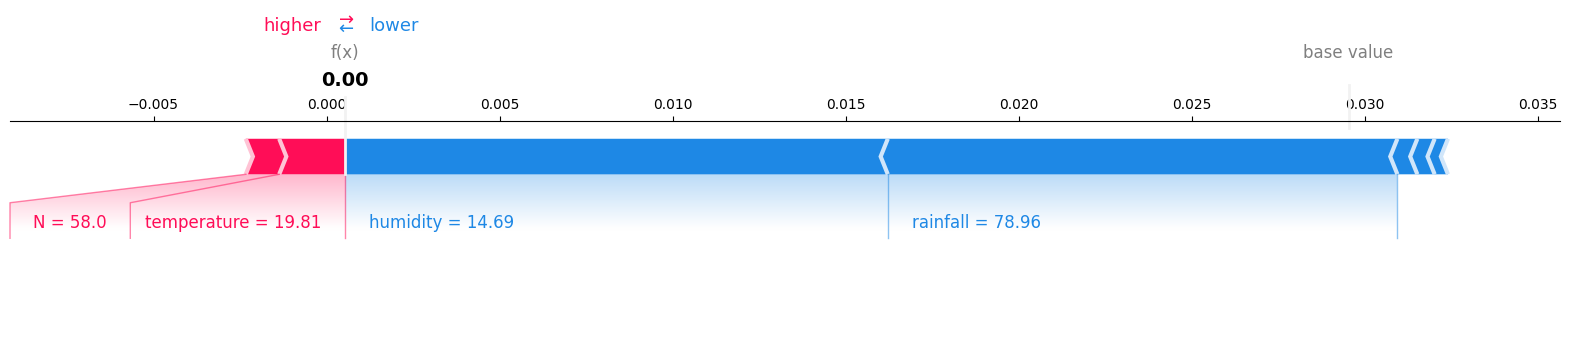


📈 Crop Improvement Suggestions:
✅ N supports rice suitability (value: 58.0)
⚠️ P is reducing rice suitability (value: 63.0)
⚠️ K is reducing rice suitability (value: 81.0)
✅ temperature supports rice suitability (value: 19.81)
⚠️ humidity is reducing rice suitability (value: 14.69)
⚠️ ph is reducing rice suitability (value: 6.51)
⚠️ rainfall is reducing rice suitability (value: 78.96)

✅ EXECUTION COMPLETED SUCCESSFULLY


In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# ------------------------------------------------------------
# 1️⃣ Load Dataset
# ------------------------------------------------------------
data = pd.read_csv("/content/Crop_recommendation.csv")

X = data.drop("label", axis=1)
y = data["label"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# ------------------------------------------------------------
# 2️⃣ Train-Test Split
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=5
)

# ------------------------------------------------------------
# 3️⃣ Scaling (for SVM & KNN)
# ------------------------------------------------------------
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# 4️⃣ Models
# ------------------------------------------------------------
gb = GradientBoostingClassifier(
    n_estimators=350,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

svm = SVC(
    kernel="rbf",
    C=8,
    gamma="scale",
    probability=True,
    random_state=42
)

knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    metric="euclidean"
)

hybrid_model = VotingClassifier(
    estimators=[
        ("GradientBoosting", gb),
        ("SVM", svm),
        ("KNN", knn)
    ],
    voting="soft",
    weights=[3, 2, 2]
)

# ------------------------------------------------------------
# 5️⃣ Train Hybrid Model
# ------------------------------------------------------------
print("\n⏳ Training Hybrid Model...")
hybrid_model.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# 6️⃣ Evaluation (same style as your 2nd code)
# ------------------------------------------------------------
y_pred = hybrid_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print("\n🏆 HYBRID MODEL ACCURACY:", accuracy)
print("\n📌 Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# ------------------------------------------------------------
# 7️⃣ SHAP Explainer (Model-Agnostic, Multiclass Safe)
# ------------------------------------------------------------
background = shap.sample(X_train_scaled, 100)

explainer = shap.KernelExplainer(
    hybrid_model.predict_proba,
    background
)

# ------------------------------------------------------------
# 8️⃣ USER INPUT
# ------------------------------------------------------------
print("\nEnter soil and climate values:")

user_input = {
    "N": float(input("Nitrogen (N): ")),
    "P": float(input("Phosphorus (P): ")),
    "K": float(input("Potassium (K): ")),
    "temperature": float(input("Temperature (°C): ")),
    "humidity": float(input("Humidity (%): ")),
    "ph": float(input("pH: ")),
    "rainfall": float(input("Rainfall (mm): "))
}

user_df = pd.DataFrame([user_input])
user_scaled = scaler.transform(user_df)

# ------------------------------------------------------------
# 9️⃣ Predict Best Crop
# ------------------------------------------------------------
predicted_class = hybrid_model.predict(user_scaled)[0]
predicted_crop = label_encoder.inverse_transform([predicted_class])[0]

print("\n🌱 Recommended Crop:", predicted_crop)

# ------------------------------------------------------------
# 🔟 OPTIONAL: Explain a Specific Crop (same logic as 1st code)
# ------------------------------------------------------------
crop_name = input("\nEnter crop name to analyze (or press Enter to skip): ")

if crop_name != "":
    crop_id = label_encoder.transform([crop_name])[0]

    shap_values = explainer.shap_values(user_scaled, nsamples=100)

    # ---- Handle SHAP output safely ----
    if isinstance(shap_values, list):
        shap_vals = shap_values[crop_id][0]
        expected_val = explainer.expected_value[crop_id]
    else:
        shap_vals = shap_values[0, :, crop_id]
        expected_val = explainer.expected_value[crop_id]

    print(f"\n🔍 Explaining crop: {crop_name}")

    shap.force_plot(
        expected_val,
        shap_vals,
        user_df.iloc[0],
        matplotlib=True
    )

    # --------------------------------------------------------
    # 🔟 Improvement Suggestions
    # --------------------------------------------------------
    print("\n📈 Crop Improvement Suggestions:")

    for f, val, shap_val in zip(user_df.columns,
                                user_df.iloc[0],
                                shap_vals):
        if shap_val < 0:
            print(f"⚠️ {f} is reducing {crop_name} suitability (value: {val})")
        else:
            print(f"✅ {f} supports {crop_name} suitability (value: {val})")

print("\n✅ EXECUTION COMPLETED SUCCESSFULLY")

In [ ]:
# ============================================================
# 🌱 HYBRID CROP RECOMMENDATION + USER INPUT + SHAP EXPLANATION
# ============================================================

!pip install -q shap xgboost

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

# ============================================================
# 1️⃣ LOAD DATASET
# ============================================================
data = pd.read_csv("/content/Crop_recommendation.csv")

X = data.drop("label", axis=1)
y = data["label"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# ============================================================
# 2️⃣ TRAIN-TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ============================================================
# 3️⃣ SCALING (FOR SVM)
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# 4️⃣ DEFINE MODELS
# ============================================================
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

rf = RandomForestClassifier(n_estimators=400, random_state=42)

svm = SVC(kernel="rbf", C=10, gamma="scale", probability=True)

# Hybrid Model (Soft Voting)
hybrid_model = VotingClassifier(
    estimators=[
        ("XGBoost", xgb),
        ("RandomForest", rf),
        ("SVM", svm)
    ],
    voting="soft"
)

# ============================================================
# 5️⃣ TRAIN MODEL
# ============================================================
hybrid_model.fit(X_train_scaled, y_train)

# ============================================================
# 6️⃣ MODEL EVALUATION
# ============================================================
y_pred = hybrid_model.predict(X_test_scaled)

# ✅ High Precision Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Model Accuracy: {accuracy:.9f}")
print(f"🎯 Accuracy Percentage: {accuracy * 100:.4f}%")

# ✅ Classification Report
class_names = label_encoder.inverse_transform(sorted(set(y_test)))

print("\n📌 Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

print("\n📊 Number of Test Samples:", len(y_test))

# ============================================================
# 7️⃣ TRAIN XGBOOST FOR SHAP (ON ORIGINAL DATA)
# ============================================================
xgb.fit(X_train, y_train)
explainer = shap.TreeExplainer(xgb)

# ============================================================
# 8️⃣ USER INPUT
# ============================================================
print("\nEnter soil and climate values:")

user_input = {
    "N": float(input("Nitrogen (N): ")),
    "P": float(input("Phosphorus (P): ")),
    "K": float(input("Potassium (K): ")),
    "temperature": float(input("Temperature (°C): ")),
    "humidity": float(input("Humidity (%): ")),
    "ph": float(input("pH: ")),
    "rainfall": float(input("Rainfall (mm): "))
}

user_df = pd.DataFrame([user_input])

# ============================================================
# 9️⃣ PREDICT BEST CROP
# ============================================================
user_scaled = scaler.transform(user_df)

predicted_class = hybrid_model.predict(user_scaled)[0]
predicted_crop = label_encoder.inverse_transform([predicted_class])[0]

print("\n🌱 Recommended Crop:", predicted_crop)

# ============================================================
# 🔟 SHAP EXPLANATION (OPTIONAL)
# ============================================================
crop_name = input("\nEnter crop name to analyze (or press Enter to skip): ")

if crop_name != "":
    try:
        crop_id = label_encoder.transform([crop_name])[0]

        shap_values = explainer.shap_values(user_df)

        print(f"\n🔍 Explaining crop: {crop_name}")

        # Force Plot
        shap.force_plot(
            explainer.expected_value[crop_id],
            shap_values[0][:, crop_id],
            user_df.iloc[0],
            matplotlib=True
        )

        plt.show()

        # ============================================================
        # 1️⃣1️⃣ IMPROVEMENT SUGGESTIONS
        # ============================================================
        print("\n📈 Crop Improvement Suggestions:")

        feature_names = user_df.columns
        contribs = shap_values[0][:, crop_id]

        for f, val, shap_val in zip(feature_names, user_df.iloc[0], contribs):
            if shap_val < 0:
                print(f"⚠️ {f} is reducing {crop_name} suitability (value: {val})")
            else:
                print(f"✅ {f} supports {crop_name} (value: {val})")

    except:
        print("❌ Invalid crop name. Please enter a valid crop from dataset.")

# ============================================================
# ✅ END
# ============================================================


🎯 Model Accuracy: 0.995454545
🎯 Accuracy Percentage: 99.5455%

📌 Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00   

Saving Crop_recommendation.csv to Crop_recommendation (1).csv
✅ Dataset Loaded Successfully


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


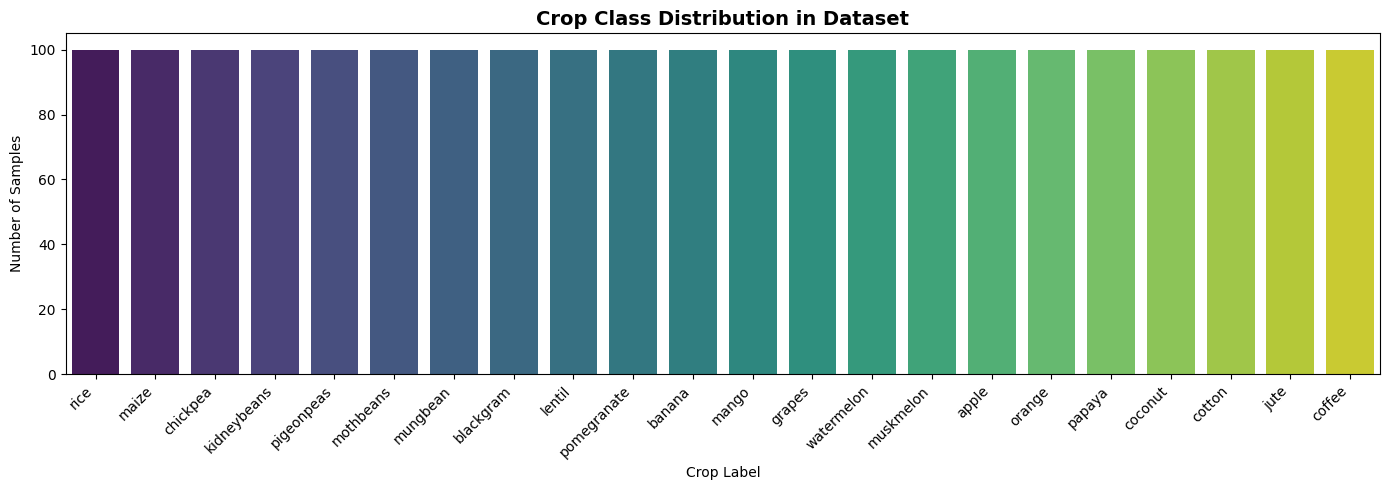

✅ Graph 1: Class Distribution saved


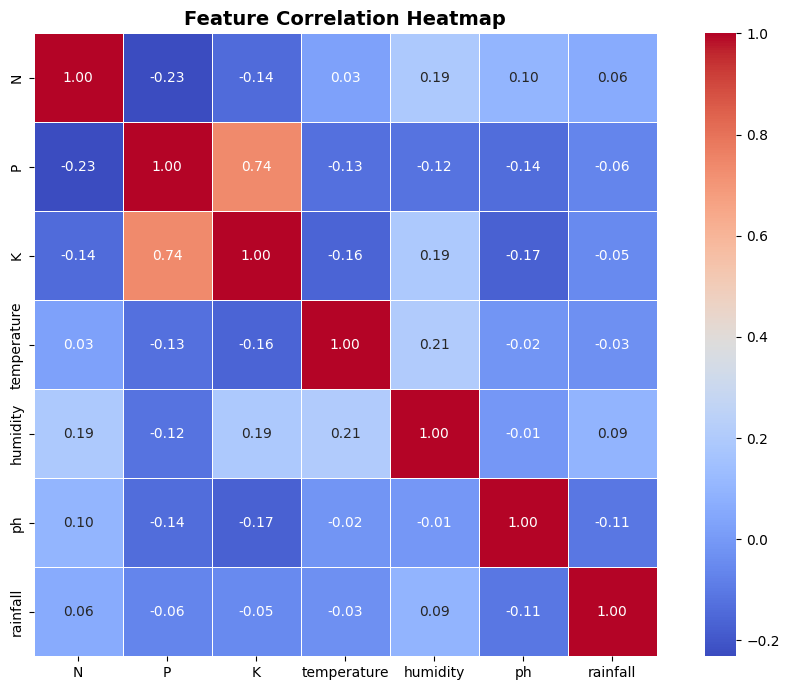

✅ Graph 2: Correlation Heatmap saved

🚀 Training all models...

🎯 Random Forest Accuracy  : 0.9955
🎯 Extra Trees Accuracy    : 0.9955
🎯 XGBoost Accuracy        : 0.9932
🎯 Hybrid (Stacking) Acc   : 0.9955

               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00    

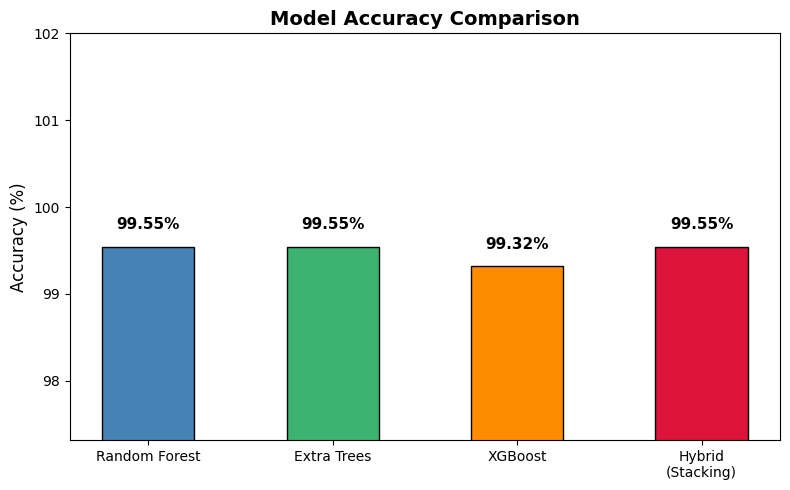

✅ Graph 3: Model Accuracy Comparison saved


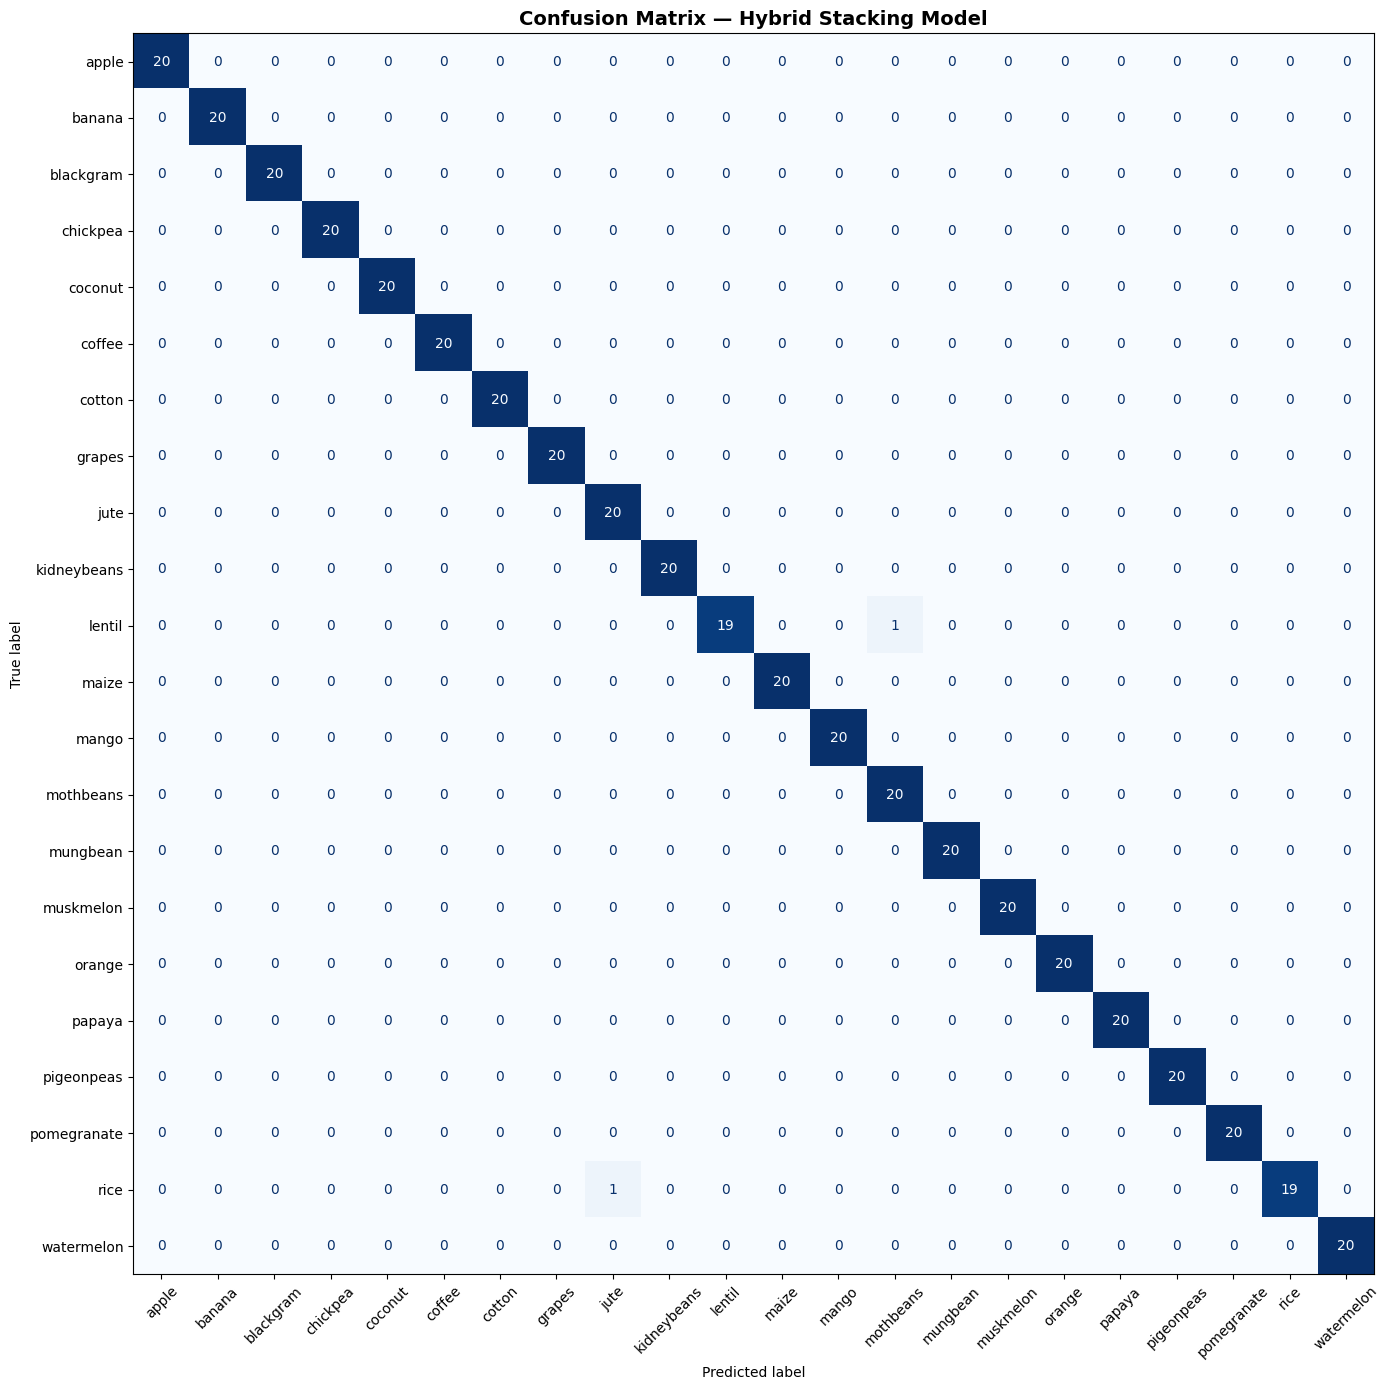

✅ Graph 4: Confusion Matrix saved

🔍 Computing SHAP values (this may take a few minutes)...


  0%|          | 0/100 [00:00<?, ?it/s]

✅ SHAP values computed. Number of classes: 100


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 1000x600 with 0 Axes>

In [ ]:
# ============================================================
# HYBRID CROP RECOMMENDATION + SHAP EXPLANATION + ALL GRAPHS
# ============================================================

!pip install -q shap xgboost

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from google.colab import files

# ============================================================
# LOAD DATA
# ============================================================
uploaded = files.upload()
data = pd.read_csv(list(uploaded.keys())[0])
print("✅ Dataset Loaded Successfully")
display(data.head())

# ============================================================
# GRAPH 1 — CLASS DISTRIBUTION
# ============================================================
plt.figure(figsize=(14, 5))
class_counts = data["label"].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Crop Class Distribution in Dataset", fontsize=14, fontweight='bold')
plt.xlabel("Crop Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("✅ Graph 1: Class Distribution saved")

# ============================================================
# GRAPH 2 — FEATURE CORRELATION HEATMAP
# ============================================================
plt.figure(figsize=(10, 7))
corr = data.drop("label", axis=1).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
print("✅ Graph 2: Correlation Heatmap saved")

# ============================================================
# FEATURES & TARGET
# ============================================================
X = data.drop("label", axis=1)
y = data["label"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2, random_state=42, stratify=y_encoded
)

X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df  = pd.DataFrame(X_test,  columns=X.columns)

# ============================================================
# MODELS
# ============================================================
rf  = RandomForestClassifier(n_estimators=400, random_state=42)
et  = ExtraTreesClassifier(n_estimators=400,  random_state=42)
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(np.unique(y_encoded)),
    eval_metric="mlogloss",
    random_state=42
)
meta_model  = LogisticRegression(max_iter=1000)
stack_model = StackingClassifier(
    estimators=[("rf", rf), ("xgb", xgb), ("et", et)],
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

# ============================================================
# TRAIN ALL MODELS
# ============================================================
print("\n🚀 Training all models...")

rf.fit(X_train_df, y_train)
et.fit(X_train_df, y_train)
xgb.fit(X_train_df, y_train)
stack_model.fit(X_train_df, y_train)

acc_rf    = accuracy_score(y_test, rf.predict(X_test_df))
acc_et    = accuracy_score(y_test, et.predict(X_test_df))
acc_xgb   = accuracy_score(y_test, xgb.predict(X_test_df))
acc_stack = accuracy_score(y_test, stack_model.predict(X_test_df))

y_pred = stack_model.predict(X_test_df)

print(f"\n🎯 Random Forest Accuracy  : {acc_rf:.4f}")
print(f"🎯 Extra Trees Accuracy    : {acc_et:.4f}")
print(f"🎯 XGBoost Accuracy        : {acc_xgb:.4f}")
print(f"🎯 Hybrid (Stacking) Acc   : {acc_stack:.4f}")
print("\n", classification_report(y_test, y_pred,
                                   target_names=label_encoder.classes_))

# ============================================================
# GRAPH 3 — MODEL ACCURACY COMPARISON
# ============================================================
model_names = ["Random Forest", "Extra Trees", "XGBoost", "Hybrid\n(Stacking)"]
accuracies  = [acc_rf, acc_et, acc_xgb, acc_stack]
colors      = ["steelblue", "mediumseagreen", "darkorange", "crimson"]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, [a * 100 for a in accuracies],
               color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.2,
             f"{acc*100:.2f}%", ha='center', fontsize=11, fontweight='bold')
plt.ylim(min(accuracies) * 100 - 2, 102)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Model Accuracy Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("model_accuracy_comparison.png", dpi=150)
plt.show()
print("✅ Graph 3: Model Accuracy Comparison saved")

# ============================================================
# GRAPH 4 — CONFUSION MATRIX
# ============================================================
plt.figure(figsize=(16, 14))
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=label_encoder.classes_)
disp.plot(cmap="Blues", xticks_rotation=45, ax=plt.gca(), colorbar=False)
plt.title("Confusion Matrix — Hybrid Stacking Model",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Graph 4: Confusion Matrix saved")

# ============================================================
# SHAP EXPLAINER SETUP
# ============================================================
print("\n🔍 Computing SHAP values (this may take a few minutes)...")
background     = X_train_df.sample(50, random_state=42).reset_index(drop=True)
X_test_sample  = X_test_df.sample(100, random_state=42).reset_index(drop=True)

explainer   = shap.KernelExplainer(stack_model.predict_proba, background)
shap_values = explainer.shap_values(X_test_sample)

# shap_values is a list of (100, n_features) arrays — one per class
print(f"✅ SHAP values computed. Number of classes: {len(shap_values)}")

# ============================================================
# GRAPH 5 — SHAP SUMMARY BAR PLOT (All Classes Averaged)
# ============================================================
# Average absolute SHAP across all classes → shape: (100, n_features)
shap_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_mean,
    X_test_sample,
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance — Average Across All Crops",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_summary_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 5: SHAP Summary Bar Plot saved")

# ============================================================
# GRAPH 6 — SHAP BEESWARM PLOT (Single Class)
# ============================================================
# Using class index 0 — change to any crop index you want
class_idx = 0
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values[class_idx],   # shape: (100, n_features) ✅
    X_test_sample,
    plot_type="dot",
    show=False
)
plt.title(f"SHAP Beeswarm — Crop: {label_encoder.classes_[class_idx]}",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 6: SHAP Beeswarm Plot saved")

# ============================================================
# GRAPH 7 — SHAP FEATURE IMPORTANCE BAR (Mean |SHAP| per feature)
# ============================================================
mean_shap_per_feature = np.mean(shap_mean, axis=0)
feat_df = pd.DataFrame({
    "Feature"    : X.columns,
    "Mean |SHAP|": mean_shap_per_feature
}).sort_values("Mean |SHAP|", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(feat_df["Feature"], feat_df["Mean |SHAP|"],
         color="steelblue", edgecolor='black')
plt.xlabel("Mean |SHAP Value|", fontsize=12)
plt.title("Feature Importance — Mean Absolute SHAP",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_feature_importance.png", dpi=150)
plt.show()
print("✅ Graph 7: SHAP Feature Importance saved")

# ============================================================
# USER INPUT — SINGLE CROP PREDICTION
# ============================================================
def get_user_input(feature_names):
    print("\n🧪 Enter soil and climate values:")
    user_data = {}
    for feature in feature_names:
        user_data[feature] = float(input(f"  {feature}: "))
    return pd.DataFrame([user_data])

user_input_df        = get_user_input(X.columns)
user_input_scaled    = scaler.transform(user_input_df)
user_input_scaled_df = pd.DataFrame(user_input_scaled, columns=X.columns)

predicted_class = stack_model.predict(user_input_scaled_df)[0]
predicted_crop  = label_encoder.inverse_transform([predicted_class])[0]
print(f"\n🌱 Recommended Crop: {predicted_crop}")

crop_name = input("\nEnter crop name to explain (or press Enter for predicted crop): ")
crop_to_explain = predicted_crop if crop_name.strip() == "" else crop_name
crop_index      = (predicted_class if crop_name.strip() == ""
                   else label_encoder.transform([crop_name])[0])

# ============================================================
# SHAP VALUES FOR USER INPUT
# ============================================================
shap_vals_user = explainer.shap_values(user_input_scaled_df)
n_features     = X.shape[1]

shap_vector = (shap_vals_user[crop_index]
               if isinstance(shap_vals_user, list)
               else shap_vals_user)
shap_vector = np.array(shap_vector).reshape(-1, n_features)[0]

expected_value = (explainer.expected_value[crop_index]
                  if isinstance(explainer.expected_value, (list, np.ndarray))
                  else explainer.expected_value)

# ============================================================
# GRAPH 8 — SHAP FORCE PLOT (Single Prediction)
# ============================================================
print(f"\n🔍 SHAP Force Plot for: {crop_to_explain}")
shap.force_plot(
    expected_value,
    shap_vector,
    user_input_df,
    matplotlib=True
)
plt.title(f"SHAP Force Plot — {crop_to_explain}",
          fontsize=13, fontweight='bold', pad=20)
plt.savefig("shap_force_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 8: SHAP Force Plot saved")

# ============================================================
# CROP IMPROVEMENT SUGGESTIONS
# ============================================================
def pretty_crop_report(crop_name, shap_vector, user_input_df):
    print(f"\n🌾 Feature Analysis for '{crop_name}':\n")
    rows = []
    for feature, shap_val in zip(X.columns, shap_vector):
        value  = round(float(user_input_df[feature].values[0]), 4)
        status = "✅ Supports" if shap_val >= 0 else "⚠️  Reduces suitability"
        rows.append({
            "Feature": feature,
            "Value"  : value,
            "SHAP"   : round(shap_val, 5),
            "Status" : status
        })
    report_df = pd.DataFrame(rows).sort_values("SHAP", ascending=False)
    display(report_df)

pretty_crop_report(crop_to_explain, shap_vector, user_input_df)

# ============================================================
# DOWNLOAD ALL SAVED GRAPHS
# ============================================================
print("\n📥 Downloading all graphs...")
for f in [
    "class_distribution.png",
    "correlation_heatmap.png",
    "model_accuracy_comparison.png",
    "confusion_matrix.png",
    "shap_summary_bar.png",
    "shap_beeswarm.png",
    "shap_feature_importance.png",
    "shap_force_plot.png"
]:
    files.download(f)

print("\n✅ ALL 8 GRAPHS GENERATED AND DOWNLOADED SUCCESSFULLY")

Saving Crop_recommendation.csv to Crop_recommendation (3).csv
✅ Dataset Loaded Successfully


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


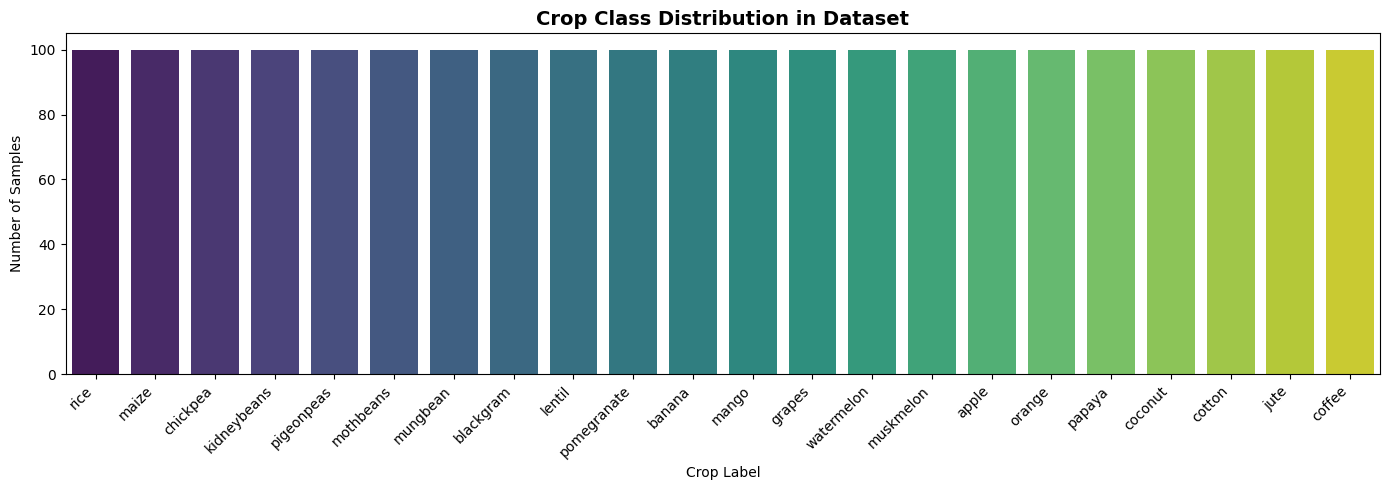

✅ Graph 1: Class Distribution saved


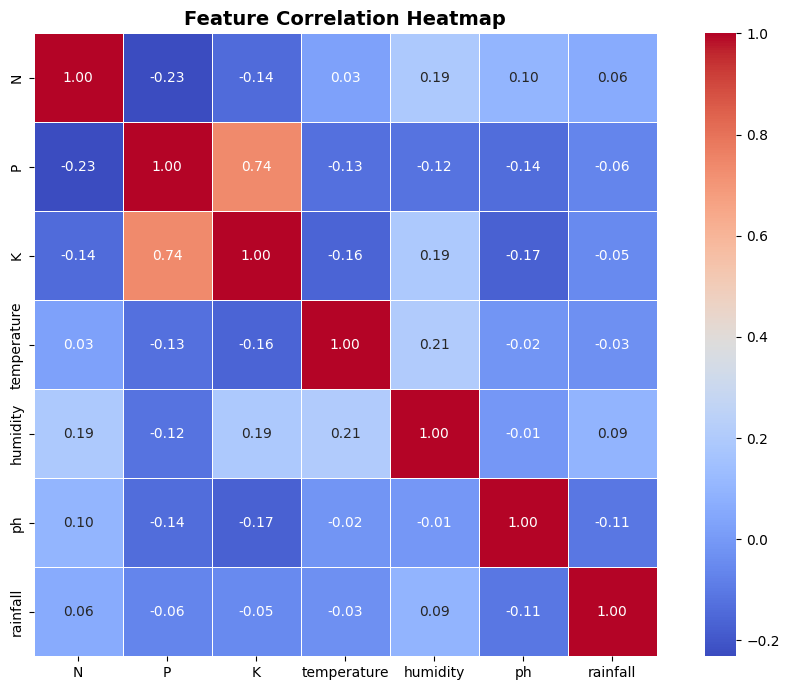

✅ Graph 2: Correlation Heatmap saved

🚀 Training all models...

🎯 XGBoost Accuracy       : 0.9909
🎯 Random Forest Accuracy : 0.9955
🎯 SVM Accuracy           : 0.9886
🎯 Hybrid (Voting) Acc    : 0.9955

📌 Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans     

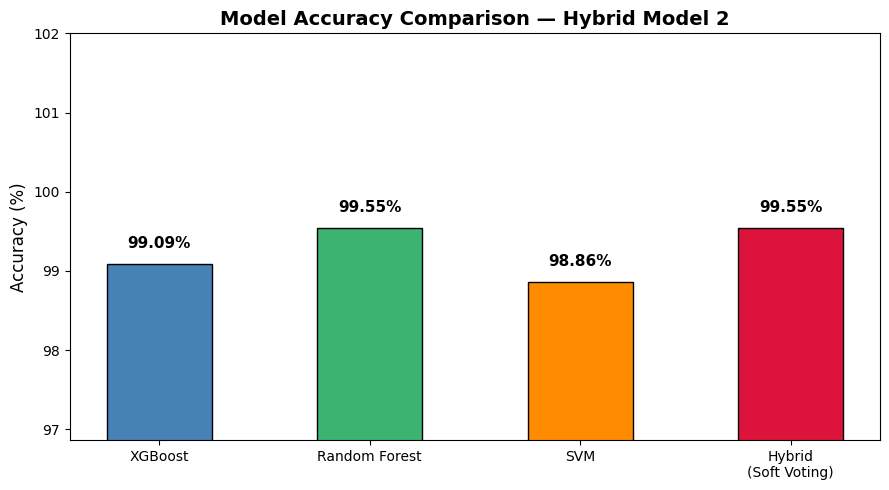

✅ Graph 3: Model Accuracy Comparison saved


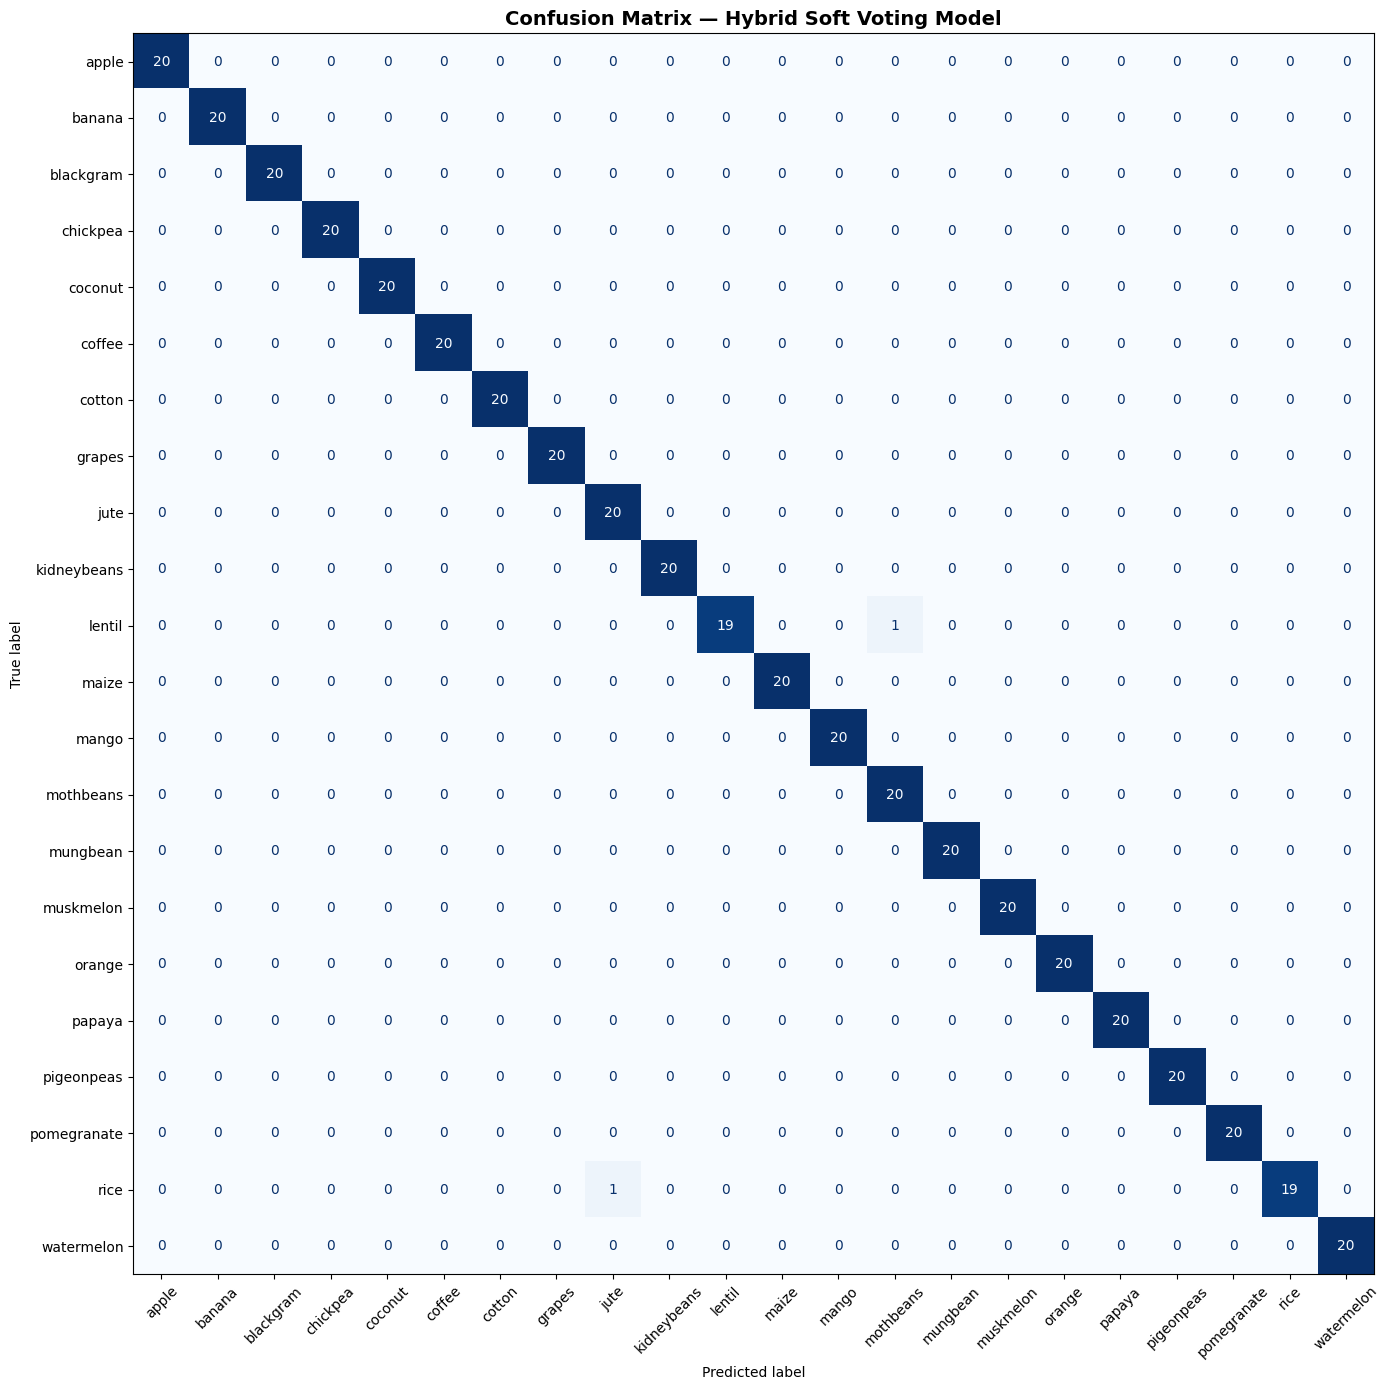

✅ Graph 4: Confusion Matrix saved

🔍 Training XGBoost for SHAP explanation...

📊 Computing SHAP values for test set...


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 1000x600 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, accuracy_score,
                              confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from google.colab import files

# ============================================================
# 1️⃣ LOAD DATASET
# ============================================================
uploaded = files.upload()
data = pd.read_csv(list(uploaded.keys())[0])

print("✅ Dataset Loaded Successfully")
display(data.head())

X = data.drop("label", axis=1)
y = data["label"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# ============================================================
# GRAPH 1 — CLASS DISTRIBUTION
# ============================================================
plt.figure(figsize=(14, 5))
class_counts = data["label"].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Crop Class Distribution in Dataset", fontsize=14, fontweight='bold')
plt.xlabel("Crop Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("✅ Graph 1: Class Distribution saved")

# ============================================================
# GRAPH 2 — FEATURE CORRELATION HEATMAP
# ============================================================
plt.figure(figsize=(10, 7))
corr = data.drop("label", axis=1).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
print("✅ Graph 2: Correlation Heatmap saved")

# ============================================================
# 2️⃣ TRAIN-TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2, random_state=42, stratify=y_encoded
)

# ============================================================
# 3️⃣ SCALING
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_df  = pd.DataFrame(X_test_scaled,  columns=X.columns)

# ============================================================
# 4️⃣ DEFINE MODELS
# ============================================================
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

rf  = RandomForestClassifier(n_estimators=400, random_state=42)
svm = SVC(kernel="rbf", C=10, gamma="scale", probability=True)

hybrid_model = VotingClassifier(
    estimators=[("XGBoost", xgb), ("RandomForest", rf), ("SVM", svm)],
    voting="soft"
)

# ============================================================
# 5️⃣ TRAIN ALL MODELS INDIVIDUALLY + HYBRID
# ============================================================
print("\n🚀 Training all models...")

xgb_solo = XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.9, colsample_bytree=0.9,
    objective="multi:softprob", eval_metric="mlogloss", random_state=42
)
rf_solo  = RandomForestClassifier(n_estimators=400, random_state=42)
svm_solo = SVC(kernel="rbf", C=10, gamma="scale", probability=True)

xgb_solo.fit(X_train_df, y_train)
rf_solo.fit(X_train_df, y_train)
svm_solo.fit(X_train_df, y_train)
hybrid_model.fit(X_train_df, y_train)

acc_xgb    = accuracy_score(y_test, xgb_solo.predict(X_test_df))
acc_rf     = accuracy_score(y_test, rf_solo.predict(X_test_df))
acc_svm    = accuracy_score(y_test, svm_solo.predict(X_test_df))
acc_hybrid = accuracy_score(y_test, hybrid_model.predict(X_test_df))

y_pred = hybrid_model.predict(X_test_df)

print(f"\n🎯 XGBoost Accuracy       : {acc_xgb:.4f}")
print(f"🎯 Random Forest Accuracy : {acc_rf:.4f}")
print(f"🎯 SVM Accuracy           : {acc_svm:.4f}")
print(f"🎯 Hybrid (Voting) Acc    : {acc_hybrid:.4f}")

class_names = label_encoder.inverse_transform(sorted(set(y_test)))
print("\n📌 Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# ============================================================
# GRAPH 3 — MODEL ACCURACY COMPARISON
# ============================================================
model_names = ["XGBoost", "Random Forest", "SVM", "Hybrid\n(Soft Voting)"]
accuracies  = [acc_xgb, acc_rf, acc_svm, acc_hybrid]
colors      = ["steelblue", "mediumseagreen", "darkorange", "crimson"]

plt.figure(figsize=(9, 5))
bars = plt.bar(model_names, [a * 100 for a in accuracies],
               color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.2,
             f"{acc*100:.2f}%", ha='center',
             fontsize=11, fontweight='bold')
plt.ylim(min(accuracies) * 100 - 2, 102)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Model Accuracy Comparison — Hybrid Model 2",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("model_accuracy_comparison.png", dpi=150)
plt.show()
print("✅ Graph 3: Model Accuracy Comparison saved")

# ============================================================
# GRAPH 4 — CONFUSION MATRIX
# ============================================================
plt.figure(figsize=(16, 14))
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=label_encoder.classes_)
disp.plot(cmap="Blues", xticks_rotation=45,
          ax=plt.gca(), colorbar=False)
plt.title("Confusion Matrix — Hybrid Soft Voting Model",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Graph 4: Confusion Matrix saved")

# ============================================================
# 6️⃣ TRAIN XGBOOST FOR SHAP (UNSCALED DATA)
# ============================================================
print("\n🔍 Training XGBoost for SHAP explanation...")
xgb_shap = XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.9, colsample_bytree=0.9,
    objective="multi:softprob", eval_metric="mlogloss", random_state=42
)
X_train_orig = pd.DataFrame(X_train, columns=X.columns)
X_test_orig  = pd.DataFrame(X_test,  columns=X.columns)
xgb_shap.fit(X_train_orig, y_train)
explainer = shap.TreeExplainer(xgb_shap)

# ============================================================
# GRAPH 5 — SHAP SUMMARY BAR PLOT (Global Feature Importance)
# ============================================================
print("\n📊 Computing SHAP values for test set...")
shap_values = explainer.shap_values(X_test_orig)

# Average absolute SHAP across all classes → (n_samples, n_features)
shap_mean = np.mean(np.abs(np.array(shap_values)), axis=0)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_mean,
    X_test_orig,
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance — Average Across All Crops",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_summary_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 5: SHAP Summary Bar Plot saved")

# ============================================================
# GRAPH 6 — SHAP BEESWARM (Class 0 — changeable)
# ============================================================
class_idx = 0
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values[class_idx],       # shape: (n_samples, n_features) ✅
    X_test_orig,
    plot_type="dot",
    show=False
)
plt.title(f"SHAP Beeswarm — Crop: {label_encoder.classes_[class_idx]}",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 6: SHAP Beeswarm Plot saved")

# ============================================================
# GRAPH 7 — SHAP FEATURE IMPORTANCE BAR (Mean |SHAP|)
# ============================================================
mean_shap_per_feature = np.mean(shap_mean, axis=0)
feat_df = pd.DataFrame({
    "Feature"    : X.columns,
    "Mean |SHAP|": mean_shap_per_feature
}).sort_values("Mean |SHAP|", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(feat_df["Feature"], feat_df["Mean |SHAP|"],
         color="steelblue", edgecolor='black')
plt.xlabel("Mean |SHAP Value|", fontsize=12)
plt.title("Feature Importance — Mean Absolute SHAP",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_feature_importance.png", dpi=150)
plt.show()
print("✅ Graph 7: SHAP Feature Importance saved")

# ============================================================
# 7️⃣ USER INPUT
# ============================================================
print("\n🧪 Enter soil and climate values:")
user_input = {
    "N"          : float(input("  Nitrogen (N)       : ")),
    "P"          : float(input("  Phosphorus (P)     : ")),
    "K"          : float(input("  Potassium (K)      : ")),
    "temperature": float(input("  Temperature (°C)   : ")),
    "humidity"   : float(input("  Humidity (%)       : ")),
    "ph"         : float(input("  pH                 : ")),
    "rainfall"   : float(input("  Rainfall (mm)      : "))
}

user_df     = pd.DataFrame([user_input])
user_scaled = scaler.transform(user_df)
user_scaled_df = pd.DataFrame(user_scaled, columns=X.columns)

# ============================================================
# 8️⃣ PREDICT CROP
# ============================================================
predicted_class = hybrid_model.predict(user_scaled_df)[0]
predicted_crop  = label_encoder.inverse_transform([predicted_class])[0]
print(f"\n🌱 Recommended Crop: {predicted_crop}")

# ============================================================
# 9️⃣ SHAP FORCE PLOT + SUGGESTIONS (USER INPUT)
# ============================================================
crop_name = input("\nEnter crop name to explain (or press Enter for predicted crop): ")
crop_to_explain = predicted_crop if crop_name.strip() == "" else crop_name

try:
    crop_id        = label_encoder.transform([crop_to_explain])[0]
    shap_vals_user = explainer.shap_values(user_df)

    shap_vector    = shap_vals_user[crop_id][0]   # shape: (n_features,)
    expected_val   = explainer.expected_value[crop_id]

    # ============================================================
    # GRAPH 8 — SHAP FORCE PLOT (Single Prediction)
    # ============================================================
    print(f"\n🔍 SHAP Force Plot for: {crop_to_explain}")
    shap.force_plot(
        expected_val,
        shap_vector,
        user_df, # Changed from user_df.iloc[0] to user_df
        matplotlib=True
    )
    plt.title(f"SHAP Force Plot — {crop_to_explain}",
              fontsize=13, fontweight='bold', pad=20)
    plt.savefig("shap_force_plot.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Graph 8: SHAP Force Plot saved")

    # ============================================================
    # CROP IMPROVEMENT SUGGESTIONS
    # ============================================================
    print(f"\n🌾 Feature Analysis for '{crop_to_explain}':\n")
    rows = []
    for feature, val, shap_val in zip(X.columns, user_df.iloc[0], shap_vector):
        status = "✅ Supports" if shap_val >= 0 else "⚠️  Reduces suitability"
        rows.append({
            "Feature": feature,
            "Value"  : round(float(val), 4),
            "SHAP"   : round(float(shap_val), 5),
            "Status" : status
        })
    report_df = pd.DataFrame(rows).sort_values("SHAP", ascending=False)
    display(report_df)

except Exception as e:
    print(f"❌ Error: {e}. Please enter a valid crop name.")

# ============================================================
# 📥 DOWNLOAD ALL GRAPHS
# ============================================================
print("\n📥 Downloading all graphs...")
for f in [
    "class_distribution.png",
    "correlation_heatmap.png",
    "model_accuracy_comparison.png",
    "confusion_matrix.png",
    "shap_summary_bar.png",
    "shap_beeswarm.png",
    "shap_feature_importance.png",
    "shap_force_plot.png"
]:
    files.download(f)

print("\n✅ ALL 8 GRAPHS GENERATED AND DOWNLOADED SUCCESSFULLY")


Saving Crop_recommendation.csv to Crop_recommendation (4).csv
Dataset Loaded Successfully


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice



Training Hybrid Stacking Model...

Accuracy: 0.9954545454545455
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange    

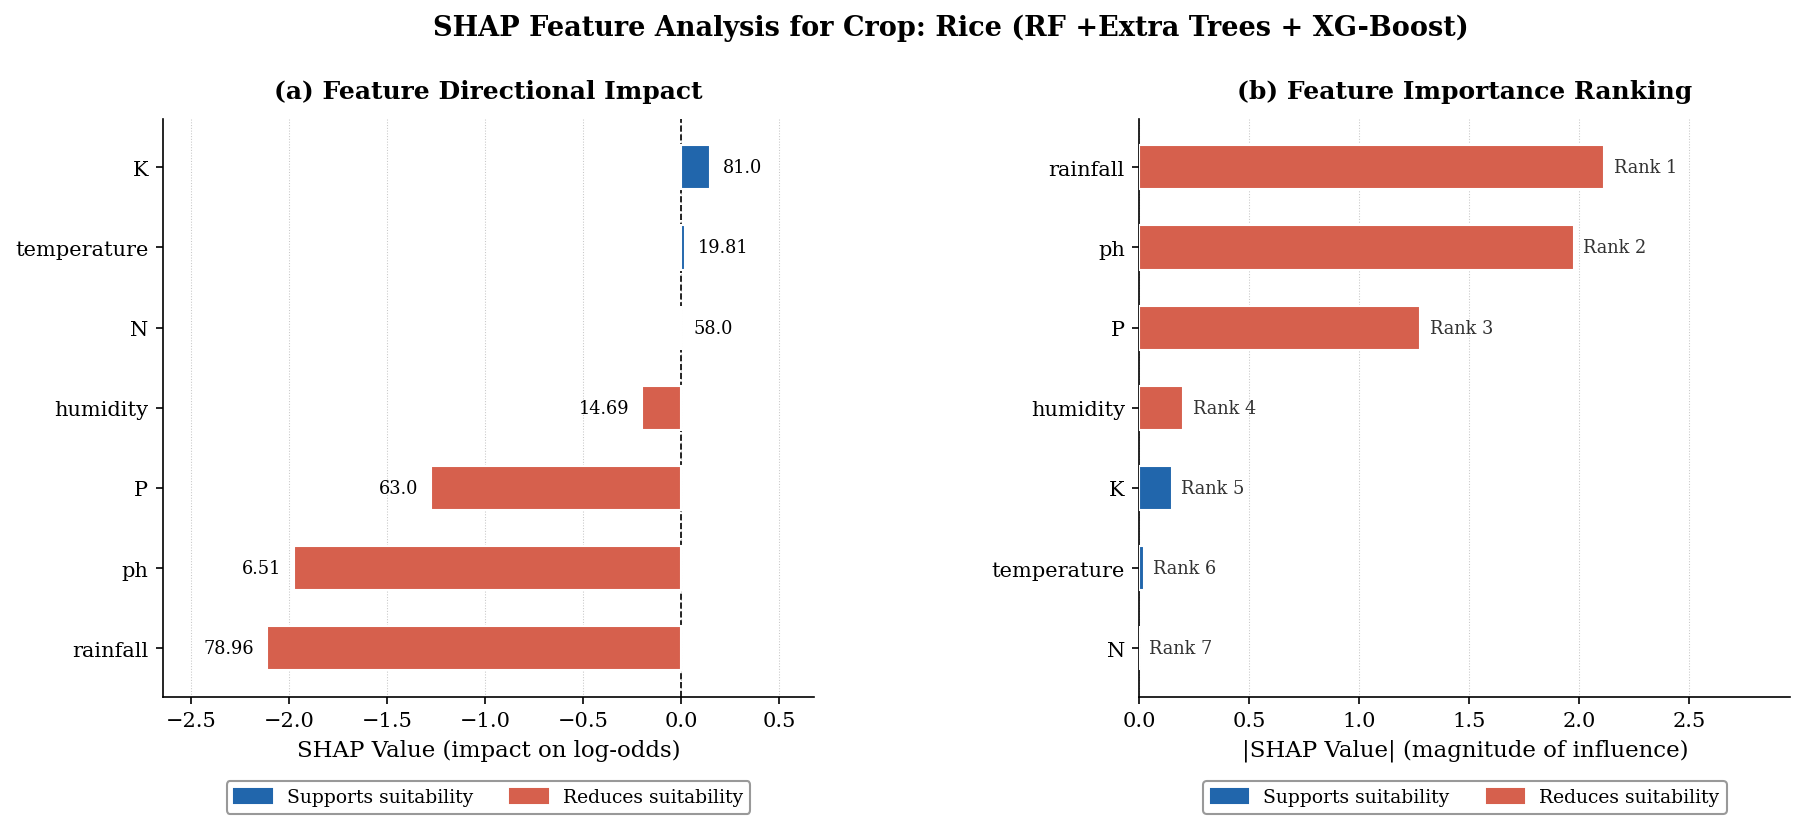


Saved: shap_journal_rice.png  (300 DPI — journal ready)

Crop Improvement Suggestions for 'rice':

  [-] rainfall        reduces   'rice' suitability  (value: 78.96,  SHAP: -2.1136999130249023)
  [-] ph              reduces   'rice' suitability  (value: 6.51,  SHAP: -1.9736000299453735)
  [-] P               reduces   'rice' suitability  (value: 63.0,  SHAP: -1.2764999866485596)
  [-] humidity        reduces   'rice' suitability  (value: 14.69,  SHAP: -0.19949999451637268)
  [+] N               supports  'rice'          (value: 58.0,  SHAP: +0.0)
  [+] temperature     supports  'rice'          (value: 19.81,  SHAP: +0.019999999552965164)
  [+] K               supports  'rice'          (value: 81.0,  SHAP: +0.14740000665187836)

EXECUTION COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# HYBRID CROP RECOMMENDATION + SINGLE-CROP SHAP EXPLANATION
# JOURNAL-QUALITY VISUALIZATION
# ============================================================

!pip install -q shap xgboost

import numpy as np
import pandas as pd
import shap
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from google.colab import files

# ============================================================
# JOURNAL FONT SETTINGS
# ============================================================
matplotlib.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif"],
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        150,
    "savefig.dpi":       300,
})

# ============================================================
# LOAD DATA
# ============================================================
uploaded = files.upload()
data = pd.read_csv(list(uploaded.keys())[0])

print("Dataset Loaded Successfully")
display(data.head())

# ============================================================
# FEATURES & TARGET
# ============================================================
X = data.drop("label", axis=1)
y = data["label"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_train_df  = pd.DataFrame(X_train, columns=X.columns)
X_test_df   = pd.DataFrame(X_test,  columns=X.columns)

# ============================================================
# MODELS
# ============================================================
rf = RandomForestClassifier(n_estimators=400, random_state=42)
et = ExtraTreesClassifier(n_estimators=400, random_state=42)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(np.unique(y_encoded)),
    eval_metric="mlogloss",
    random_state=42
)

meta_model = LogisticRegression(max_iter=1000)

stack_model = StackingClassifier(
    estimators=[("rf", rf), ("xgb", xgb), ("et", et)],
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

# ============================================================
# TRAIN STACKING MODEL
# ============================================================
print("\nTraining Hybrid Stacking Model...")
stack_model.fit(X_train_df, y_train)

y_pred = stack_model.predict(X_test_df)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# ============================================================
# TRAIN XGBOOST SEPARATELY FOR SHAP
# ============================================================
print("\nTraining XGBoost for SHAP explanation...")
xgb_shap = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(np.unique(y_encoded)),
    eval_metric="mlogloss",
    random_state=42
)
xgb_shap.fit(X_train_df, y_train)
explainer = shap.TreeExplainer(xgb_shap)

# ============================================================
# USER INPUT
# ============================================================
def get_user_input(feature_names):
    print("\nEnter soil and climate values:")
    user_data = {}
    for feature in feature_names:
        user_data[feature] = float(input(f"  {feature}: "))
    return pd.DataFrame([user_data])

user_input_df        = get_user_input(X.columns)
user_input_scaled    = scaler.transform(user_input_df)
user_input_scaled_df = pd.DataFrame(user_input_scaled, columns=X.columns)

# ============================================================
# PREDICT CROP
# ============================================================
predicted_class = stack_model.predict(user_input_scaled_df)[0]
predicted_crop  = label_encoder.inverse_transform([predicted_class])[0]

print(f"\nRecommended Crop: {predicted_crop}")

# ============================================================
# CHOOSE CROP TO EXPLAIN
# ============================================================
crop_name = input("\nEnter crop name to analyze (or press Enter to use predicted crop): ")

if crop_name.strip() == "":
    crop_to_explain = predicted_crop
    crop_index      = predicted_class
else:
    crop_to_explain = crop_name.strip()
    crop_index      = label_encoder.transform([crop_to_explain])[0]

# ============================================================
# SHAP VALUES (SAFE EXTRACTION)
# ============================================================
shap_vals  = explainer.shap_values(user_input_scaled_df)
n_features = X.shape[1]

if isinstance(shap_vals, list):
    shap_vector = shap_vals[crop_index] if crop_index < len(shap_vals) else shap_vals[0]
else:
    shap_vector = shap_vals

shap_vector = np.array(shap_vector).reshape(-1, n_features)[0]

expected_value = (
    explainer.expected_value[crop_index]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value
)

# ============================================================
# JOURNAL-QUALITY SHAP VISUALIZATION
# ============================================================
print(f"\nExplaining crop: {crop_to_explain}")

feature_names = list(X.columns)
shap_series   = pd.Series(shap_vector, index=feature_names).sort_values()

# Colorblind-safe palette
COLOR_POS = "#2166ac"   # blue   — supports suitability
COLOR_NEG = "#d6604d"   # red    — reduces suitability

colors_dir  = [COLOR_POS if v >= 0 else COLOR_NEG for v in shap_series]

shap_abs    = shap_series.abs().sort_values(ascending=False)
colors_rank = [COLOR_POS if shap_series[f] >= 0 else COLOR_NEG for f in shap_abs.index]

n_feat  = len(feature_names)
fig_h   = max(5, n_feat * 0.65)
x_max   = shap_series.abs().max()

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, fig_h),
    gridspec_kw={"wspace": 0.5}
)

# ── (a) Directional Impact Chart ─────────────────────────────────────────────
bars = axes[0].barh(
    range(n_feat), shap_series.values,
    color=colors_dir, edgecolor="white", height=0.55, zorder=3
)
axes[0].set_yticks(range(n_feat))
axes[0].set_yticklabels(shap_series.index, fontsize=10)
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--", zorder=2)
axes[0].set_xlabel("SHAP Value (impact on log-odds)", fontsize=11)
axes[0].set_title("(a) Feature Directional Impact", fontsize=12, fontweight="bold", pad=10)
axes[0].grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.7, zorder=0)

# Value annotations placed outside bars — never overlapping
for bar, feat in zip(bars, shap_series.index):
    raw_val = round(float(user_input_df[feat].values[0]), 2)
    shap_v  = shap_series[feat]
    offset  = x_max * 0.03
    if shap_v >= 0:
        axes[0].text(
            shap_v + offset,
            bar.get_y() + bar.get_height() / 2,
            str(raw_val), va="center", ha="left", fontsize=8.5
        )
    else:
        axes[0].text(
            shap_v - offset,
            bar.get_y() + bar.get_height() / 2,
            str(raw_val), va="center", ha="right", fontsize=8.5
        )

# Extend x-axis so labels don't get clipped
x_left  = shap_series.min() - x_max * 0.25
x_right = shap_series.max() + x_max * 0.25
axes[0].set_xlim(x_left, x_right)

# Legend below the chart
pos_patch = mpatches.Patch(color=COLOR_POS, label="Supports suitability")
neg_patch = mpatches.Patch(color=COLOR_NEG, label="Reduces suitability")
axes[0].legend(
    handles=[pos_patch, neg_patch],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=2, fontsize=9, frameon=True, edgecolor="grey"
)

# ── (b) Importance Ranking Chart ─────────────────────────────────────────────
rank_feats  = shap_abs.index[::-1].tolist()
rank_vals   = shap_abs.values[::-1].tolist()
rank_colors = colors_rank[::-1]

axes[1].barh(
    range(n_feat), rank_vals,
    color=rank_colors, edgecolor="white", height=0.55, zorder=3
)
axes[1].set_yticks(range(n_feat))
axes[1].set_yticklabels(rank_feats, fontsize=10)
axes[1].set_xlabel("|SHAP Value| (magnitude of influence)", fontsize=11)
axes[1].set_title("(b) Feature Importance Ranking", fontsize=12, fontweight="bold", pad=10)
axes[1].grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.7, zorder=0)

# Extend x-axis for rank labels
axes[1].set_xlim(0, x_max * 1.4)

# Rank labels at end of bars
for i, (feat, val) in enumerate(zip(rank_feats, rank_vals)):
    axes[1].text(
        val + x_max * 0.02, i,
        f"Rank {n_feat - i}",
        va="center", ha="left", fontsize=8.5, color="#333333"
    )

axes[1].legend(
    handles=[pos_patch, neg_patch],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=2, fontsize=9, frameon=True, edgecolor="grey"
)

# ── Shared Figure Title ───────────────────────────────────────────────────────
fig.suptitle(
    f"SHAP Feature Analysis for Crop: {crop_to_explain.capitalize()} "
    f"(RF +Extra Trees + XG-Boost)",
    fontsize=13, fontweight="bold", y=1.02
)

output_file = f"shap_journal_{crop_to_explain}.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSaved: {output_file}  (300 DPI — journal ready)")

# ============================================================
# HUMAN-READABLE CROP IMPROVEMENT REPORT
# ============================================================
def pretty_crop_report(crop_name, shap_vector, user_input_df):
    print(f"\nCrop Improvement Suggestions for '{crop_name}':\n")
    paired = sorted(zip(X.columns, shap_vector), key=lambda x: x[1])
    for feature, shap_val in paired:
        value = round(float(user_input_df[feature].values[0]), 4)
        if shap_val >= 0:
            print(f"  [+] {feature:<15} supports  '{crop_name}'          "
                  f"(value: {value},  SHAP: +{round(shap_val, 4)})")
        else:
            print(f"  [-] {feature:<15} reduces   '{crop_name}' suitability  "
                  f"(value: {value},  SHAP: {round(shap_val, 4)})")

pretty_crop_report(crop_to_explain, shap_vector, user_input_df)

print("\nEXECUTION COMPLETED SUCCESSFULLY")

Saving Crop_recommendation.csv to Crop_recommendation (3).csv
Dataset Loaded Successfully


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice



Training Hybrid Model (GB + SVM + KNN)...

HYBRID MODEL ACCURACY: 0.9931818181818182

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.90      0.95      0.93        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00  

  0%|          | 0/1 [00:00<?, ?it/s]


Explaining crop: rice


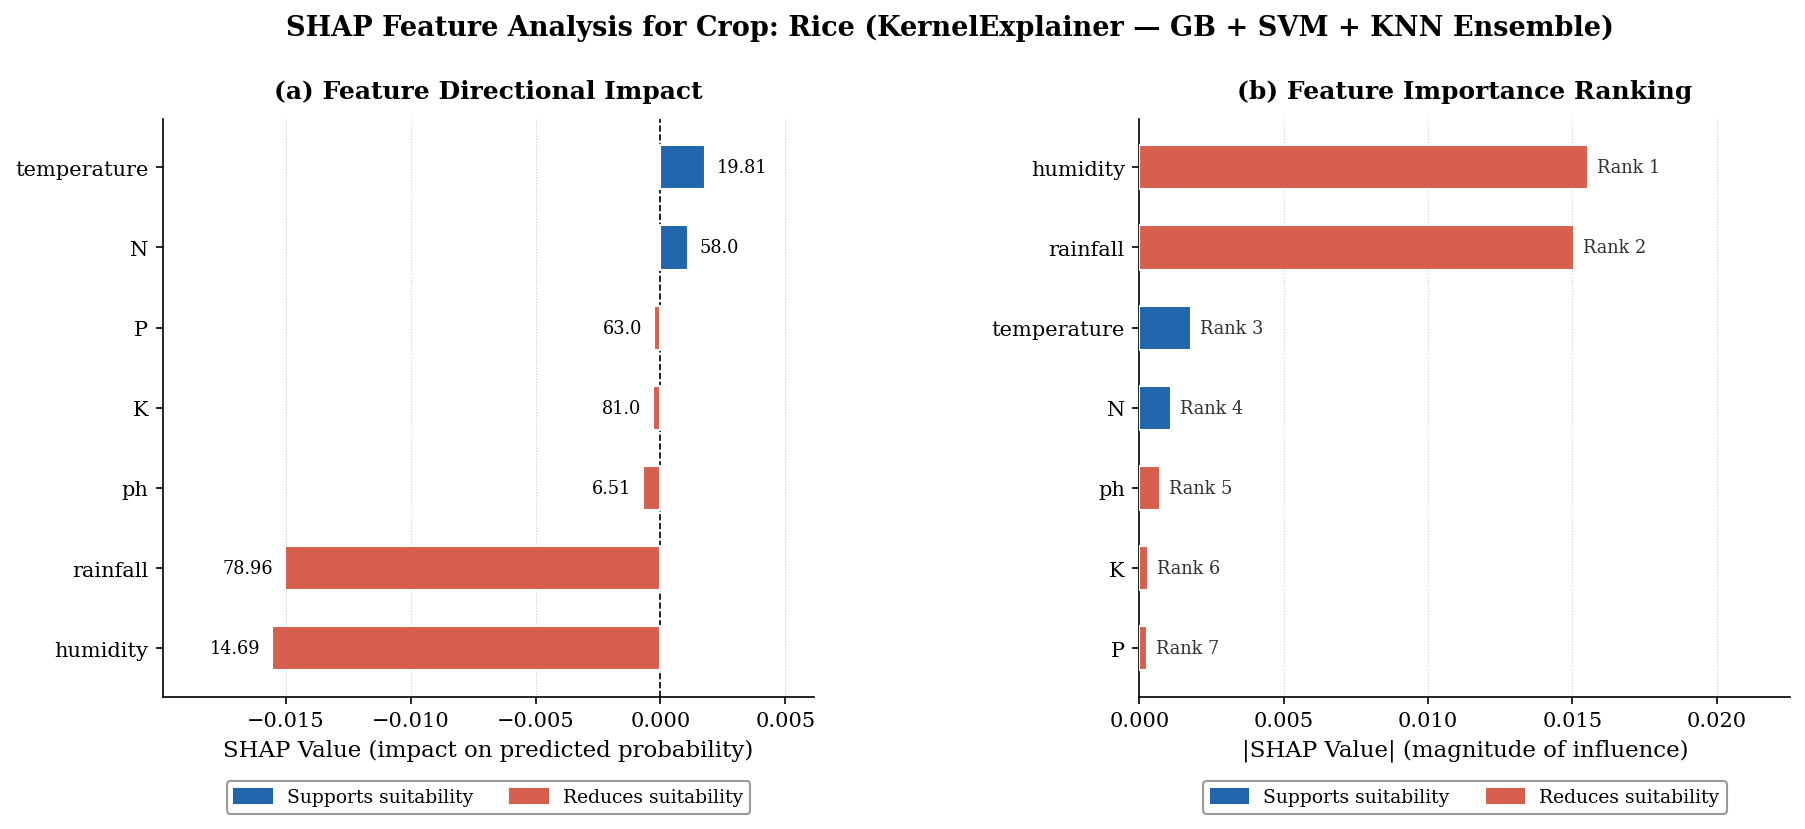


Saved: shap_journal_rice.png  (300 DPI — journal ready)

Crop Improvement Suggestions for 'rice':

  [-] humidity        reduces   'rice' suitability  (value: 14.69,  SHAP: -0.0156)
  [-] rainfall        reduces   'rice' suitability  (value: 78.96,  SHAP: -0.015)
  [-] ph              reduces   'rice' suitability  (value: 6.51,  SHAP: -0.0007)
  [-] K               reduces   'rice' suitability  (value: 81.0,  SHAP: -0.0003)
  [-] P               reduces   'rice' suitability  (value: 63.0,  SHAP: -0.0003)
  [+] N               supports  'rice'          (value: 58.0,  SHAP: +0.0011)
  [+] temperature     supports  'rice'          (value: 19.81,  SHAP: +0.0018)

EXECUTION COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# HYBRID CROP RECOMMENDATION (GB + SVM + KNN)
# + JOURNAL-QUALITY SHAP VISUALIZATION
# ============================================================

import pandas as pd
import numpy as np
import shap
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from google.colab import files

# ============================================================
# JOURNAL FONT SETTINGS
# ============================================================
matplotlib.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif"],
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        150,
    "savefig.dpi":       300,
})

# ============================================================
# 1. LOAD DATASET
# ============================================================
uploaded = files.upload()
data = pd.read_csv(list(uploaded.keys())[0])

print("Dataset Loaded Successfully")
display(data.head())

X = data.drop("label", axis=1)
y = data["label"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# ============================================================
# 2. TRAIN-TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=5
)

# ============================================================
# 3. SCALING
# ============================================================
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=X.columns)

# ============================================================
# 4. MODELS
# ============================================================
gb = GradientBoostingClassifier(
    n_estimators=350,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

svm = SVC(
    kernel="rbf",
    C=8,
    gamma="scale",
    probability=True,
    random_state=42
)

knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    metric="euclidean"
)

hybrid_model = VotingClassifier(
    estimators=[
        ("GradientBoosting", gb),
        ("SVM",              svm),
        ("KNN",              knn)
    ],
    voting="soft",
    weights=[3, 2, 2]
)

# ============================================================
# 5. TRAIN HYBRID MODEL
# ============================================================
print("\nTraining Hybrid Model (GB + SVM + KNN)...")
hybrid_model.fit(X_train_scaled, y_train)

# ============================================================
# 6. EVALUATION
# ============================================================
y_pred   = hybrid_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print("\nHYBRID MODEL ACCURACY:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# ============================================================
# 7. SHAP KERNEL EXPLAINER SETUP
# ============================================================
print("\nInitializing SHAP KernelExplainer (this may take a moment)...")
background = shap.sample(X_train_scaled, 100)
explainer  = shap.KernelExplainer(hybrid_model.predict_proba, background)

# ============================================================
# 8. USER INPUT
# ============================================================
print("\nEnter soil and climate values:")
user_input = {
    "N":           float(input("  Nitrogen (N)       : ")),
    "P":           float(input("  Phosphorus (P)     : ")),
    "K":           float(input("  Potassium (K)      : ")),
    "temperature": float(input("  Temperature (C)    : ")),
    "humidity":    float(input("  Humidity (%)       : ")),
    "ph":          float(input("  pH                 : ")),
    "rainfall":    float(input("  Rainfall (mm)      : "))
}

user_df     = pd.DataFrame([user_input])
user_scaled = scaler.transform(user_df)

# ============================================================
# 9. PREDICT BEST CROP
# ============================================================
predicted_class = hybrid_model.predict(user_scaled)[0]
predicted_crop  = label_encoder.inverse_transform([predicted_class])[0]

print(f"\nRecommended Crop: {predicted_crop}")

# ============================================================
# 10. CHOOSE CROP TO EXPLAIN
# ============================================================
crop_name = input("\nEnter crop name to analyze (or press Enter to use predicted crop): ")

if crop_name.strip() == "":
    crop_to_explain = predicted_crop
    crop_id         = predicted_class
else:
    crop_to_explain = crop_name.strip()
    crop_id         = label_encoder.transform([crop_to_explain])[0]

# ============================================================
# 11. COMPUTE SHAP VALUES
# ============================================================
print(f"\nComputing SHAP values for '{crop_to_explain}' (nsamples=100)...")
shap_values = explainer.shap_values(user_scaled, nsamples=100)

# Safe extraction for multiclass
if isinstance(shap_values, list):
    shap_vals    = shap_values[crop_id][0]
    expected_val = explainer.expected_value[crop_id]
else:
    shap_vals    = shap_values[0, :, crop_id]
    expected_val = explainer.expected_value[crop_id]

shap_vals = np.array(shap_vals).flatten()

# ============================================================
# 12. JOURNAL-QUALITY SHAP VISUALIZATION
# ============================================================
print(f"\nExplaining crop: {crop_to_explain}")

feature_names = list(X.columns)
shap_series   = pd.Series(shap_vals, index=feature_names).sort_values()

# Colorblind-safe palette
COLOR_POS = "#2166ac"   # blue       — supports suitability
COLOR_NEG = "#d6604d"   # orange-red — reduces suitability

colors_dir  = [COLOR_POS if v >= 0 else COLOR_NEG for v in shap_series]

shap_abs    = shap_series.abs().sort_values(ascending=False)
colors_rank = [COLOR_POS if shap_series[f] >= 0 else COLOR_NEG for f in shap_abs.index]

n_feat  = len(feature_names)
x_max   = shap_series.abs().max()
fig_h   = max(5, n_feat * 0.65)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, fig_h),
    gridspec_kw={"wspace": 0.5}
)

# ── (a) Directional Impact ────────────────────────────────────────────────────
bars = axes[0].barh(
    range(n_feat), shap_series.values,
    color=colors_dir, edgecolor="white", height=0.55, zorder=3
)
axes[0].set_yticks(range(n_feat))
axes[0].set_yticklabels(shap_series.index, fontsize=10)
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--", zorder=2)
axes[0].set_xlabel("SHAP Value (impact on predicted probability)", fontsize=11)
axes[0].set_title("(a) Feature Directional Impact", fontsize=12,
                  fontweight="bold", pad=10)
axes[0].grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.7, zorder=0)

# Value annotations placed outside bars — never overlapping
for bar, feat in zip(bars, shap_series.index):
    raw_val = round(float(user_df[feat].values[0]), 2)
    shap_v  = shap_series[feat]
    offset  = x_max * 0.03
    if shap_v >= 0:
        axes[0].text(shap_v + offset,
                     bar.get_y() + bar.get_height() / 2,
                     str(raw_val), va="center", ha="left", fontsize=8.5)
    else:
        axes[0].text(shap_v - offset,
                     bar.get_y() + bar.get_height() / 2,
                     str(raw_val), va="center", ha="right", fontsize=8.5)

# X-axis limits with padding so labels are never clipped
axes[0].set_xlim(
    shap_series.min() - x_max * 0.28,
    shap_series.max() + x_max * 0.28
)

# Legend below chart — never overlaps bars
pos_patch = mpatches.Patch(color=COLOR_POS, label="Supports suitability")
neg_patch = mpatches.Patch(color=COLOR_NEG, label="Reduces suitability")
axes[0].legend(
    handles=[pos_patch, neg_patch],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=2, fontsize=9, frameon=True, edgecolor="grey"
)

# ── (b) Importance Ranking ────────────────────────────────────────────────────
rank_feats  = shap_abs.index[::-1].tolist()
rank_vals   = shap_abs.values[::-1].tolist()
rank_colors = colors_rank[::-1]

axes[1].barh(
    range(n_feat), rank_vals,
    color=rank_colors, edgecolor="white", height=0.55, zorder=3
)
axes[1].set_yticks(range(n_feat))
axes[1].set_yticklabels(rank_feats, fontsize=10)
axes[1].set_xlabel("|SHAP Value| (magnitude of influence)", fontsize=11)
axes[1].set_title("(b) Feature Importance Ranking", fontsize=12,
                  fontweight="bold", pad=10)
axes[1].grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.7, zorder=0)
axes[1].set_xlim(0, x_max * 1.45)

# Rank labels at end of each bar
for i, (feat, val) in enumerate(zip(rank_feats, rank_vals)):
    axes[1].text(
        val + x_max * 0.02, i,
        f"Rank {n_feat - i}",
        va="center", ha="left", fontsize=8.5, color="#333333"
    )

axes[1].legend(
    handles=[pos_patch, neg_patch],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=2, fontsize=9, frameon=True, edgecolor="grey"
)

# ── Shared Title ──────────────────────────────────────────────────────────────
fig.suptitle(
    f"SHAP Feature Analysis for Crop: {crop_to_explain.capitalize()} "
    f"(KernelExplainer — GB + SVM + KNN Ensemble)",
    fontsize=13, fontweight="bold", y=1.02
)

output_file = f"shap_journal_{crop_to_explain}.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSaved: {output_file}  (300 DPI — journal ready)")

# ============================================================
# 13. HUMAN-READABLE CROP IMPROVEMENT REPORT
# ============================================================
def pretty_crop_report(crop_name, shap_vals, user_df, feature_names):
    print(f"\nCrop Improvement Suggestions for '{crop_name}':\n")
    paired = sorted(zip(feature_names, shap_vals), key=lambda x: x[1])
    for feature, shap_val in paired:
        value = round(float(user_df[feature].values[0]), 4)
        if shap_val >= 0:
            print(f"  [+] {feature:<15} supports  '{crop_name}'          "
                  f"(value: {value},  SHAP: +{round(shap_val, 4)})")
        else:
            print(f"  [-] {feature:<15} reduces   '{crop_name}' suitability  "
                  f"(value: {value},  SHAP: {round(shap_val, 4)})")

pretty_crop_report(crop_to_explain, shap_vals, user_df, feature_names)

print("\nEXECUTION COMPLETED SUCCESSFULLY")